<div align="center">
  <img src="https://raw.githubusercontent.com/devicons/devicon/master/icons/python/python-original.svg" width="80"/>
</div>

<h1 align="center">Aula Zero: Encontrando a Reta com Matemática Básica</h1>

<h3 align="center">PhD. Julles Mitoura</h3>

<div align="center">
  <img src="https://img.shields.io/badge/Python-3776AB?style=for-the-badge&logo=python&logoColor=white"/>
  <img src="https://img.shields.io/badge/Jupyter-F37626?style=for-the-badge&logo=jupyter&logoColor=white"/>
  <img src="https://img.shields.io/badge/NumPy-013243?style=for-the-badge&logo=numpy&logoColor=white"/>
</div>

---

## <span style="color:#1E90FF;">Problema</span>

Um **trocador de calor** tem sua eficiência monitorada diariamente. Com o tempo, incrustações reduzem essa eficiência. Precisamos:

1. **Modelar** a queda de eficiência com uma reta $y = \beta_0 + \beta_1 \cdot t$
2. **Prever** quando a eficiência atingirá 92% (momento de limpeza)

Nesta aula, vamos encontrar a reta usando **apenas matemática básica** — relações de triângulos — sem nenhuma otimização automática.

---
## <span style="color:#1E90FF;">1. Carregar os Dados</span>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
from pathlib import Path

df = pd.read_csv(Path("data/heat_exchanger.csv")).sort_values("timestamp").reset_index(drop=True)

datas = pd.to_datetime(df["timestamp"], format="%Y-%m-%d").tolist()
dia_zero = datas[0]
t = np.array([(d - dia_zero).days for d in datas], dtype=np.float64)  # tempo em dias
y = df["heat_efficiency"].to_numpy(dtype=np.float64)

print(f"Total de amostras: {len(t)}")
print(f"Período: {datas[0].date()} → {datas[-1].date()}")
print(f"Eficiência: {y.min():.2f}% a {y.max():.2f}%")
df[["timestamp", "heat_efficiency"]].head()

Total de amostras: 175
Período: 2022-01-01 → 2022-06-30
Eficiência: 93.23% a 96.45%


,timestamp,heat_efficiency
0,2022-01-01,96.454517
1,2022-01-02,96.432576
2,2022-01-03,96.410674
3,2022-01-04,96.388810
4,2022-01-05,96.366986


---
## <span style="color:#1E90FF;">2. Visualizar os Dados</span>

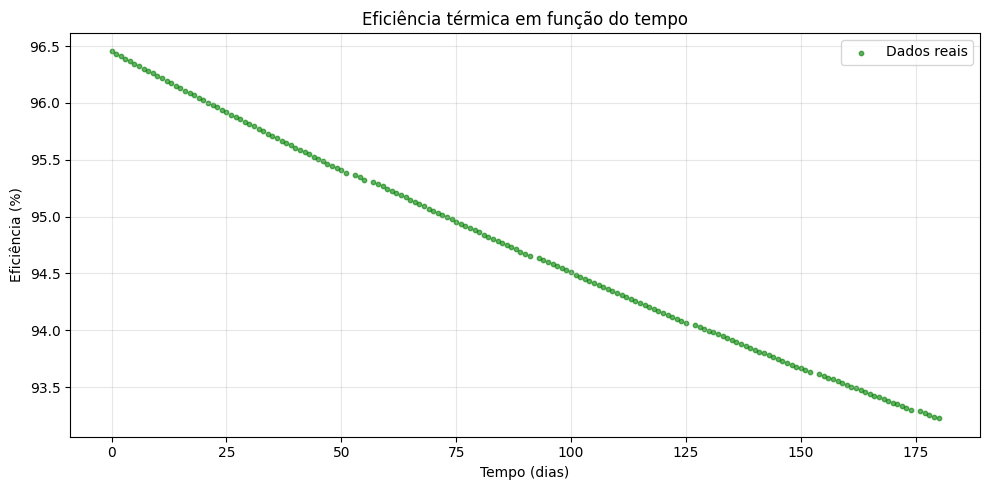

In [2]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(t, y, s=10, alpha=0.6, color="green", label="Dados reais")
ax.set_xlabel("Tempo (dias)")
ax.set_ylabel("Eficiência (%)")
ax.set_title("Eficiência térmica em função do tempo")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## <span style="color:#1E90FF;">3. A Ideia do Triângulo</span>

Uma reta tem **inclinação constante**: qualquer par de pontos sobre ela forma um triângulo retângulo com a **mesma razão** entre cateto vertical e cateto horizontal. Esse é o princípio dos **triângulos semelhantes** (Teorema de Tales).

Dados dois pontos $A = (t_1,\, y_1)$ e $B = (t_2,\, y_2)$ sobre a reta:

$$\beta_1 = \frac{\text{cateto vertical}}{\text{cateto horizontal}} = \frac{\Delta y}{\Delta t} = \frac{y_2 - y_1}{t_2 - t_1}$$

Esse valor é o **coeficiente angular** $\beta_1$ (a inclinação da reta). Com ele em mãos, substituímos um dos pontos na equação $y = \beta_0 + \beta_1 \cdot t$ para isolar o **intercepto** $\beta_0$:

$$\beta_0 = y_1 - \beta_1 \cdot t_1$$

---
## <span style="color:#1E90FF;">4. Escolher Dois Pontos de Referência</span>

Escolhemos dois instantes bem separados na série — dia 50 e dia 100 — para construir o triângulo.

In [3]:
# Índices dos pontos de referência (dia 50 e dia 100)
idx_A = 50
idx_B = 100

t1, y1 = t[idx_A], y[idx_A]
t2, y2 = t[idx_B], y[idx_B]

print(f"Ponto A → t={t1:.0f} dias, eficiência={y1:.4f}%")
print(f"Ponto B → t={t2:.0f} dias, eficiência={y2:.4f}%")
print()
print(f"Cateto horizontal (Δt): {t2 - t1:.0f} dias")
print(f"Cateto vertical   (Δy): {y2 - y1:.4f}%")

Ponto A → t=50 dias, eficiência=95.4054%
Ponto B → t=103 dias, eficiência=94.4539%

Cateto horizontal (Δt): 53 dias
Cateto vertical   (Δy): -0.9514%


---
## <span style="color:#1E90FF;">5. Calcular β₁ e β₀</span>

**Coeficiente angular** — razão dos catetos:

$$\beta_1 = \frac{\Delta y}{\Delta t} = \frac{y_B - y_A}{t_B - t_A}$$

**Intercepto** — substituindo o ponto A na equação da reta:

$$y_A = \beta_0 + \beta_1 \cdot t_A \implies \beta_0 = y_A - \beta_1 \cdot t_A$$

In [ ]:
# Coeficiente angular: cateto vertical / cateto horizontal
delta_y = y2 - y1
delta_t = t2 - t1
beta1 = delta_y / delta_t

# Intercepto: isolar β₀ usando o ponto A
beta0 = y1 - beta1 * t1

df_params = pd.DataFrame(
    {"Valor": [delta_y, delta_t, beta1, beta0]},
    index=["Δy (cateto vertical)", "Δt (cateto horizontal)", "β₁ = Δy / Δt", "β₀ = y_A − β₁·t_A"],
)

display(df_params.style
    .format("{:.6f}")
    .set_caption(f"Equação da reta:  y = {beta0:.4f} + ({beta1:.6f}) · t")
    .set_table_styles([
        {"selector": "caption",
         "props": [("font-size", "1em"), ("font-weight", "bold"), ("color", "#1E90FF")]},
        {"selector": "th",
         "props": [("background-color", "#1E90FF"), ("color", "white"), ("text-align", "center")]},
        {"selector": "td",
         "props": [("text-align", "right"), ("padding", "6px 16px")]},
    ])
)

---
## <span style="color:#1E90FF;">6. Visualizar a Reta e o Triângulo</span>

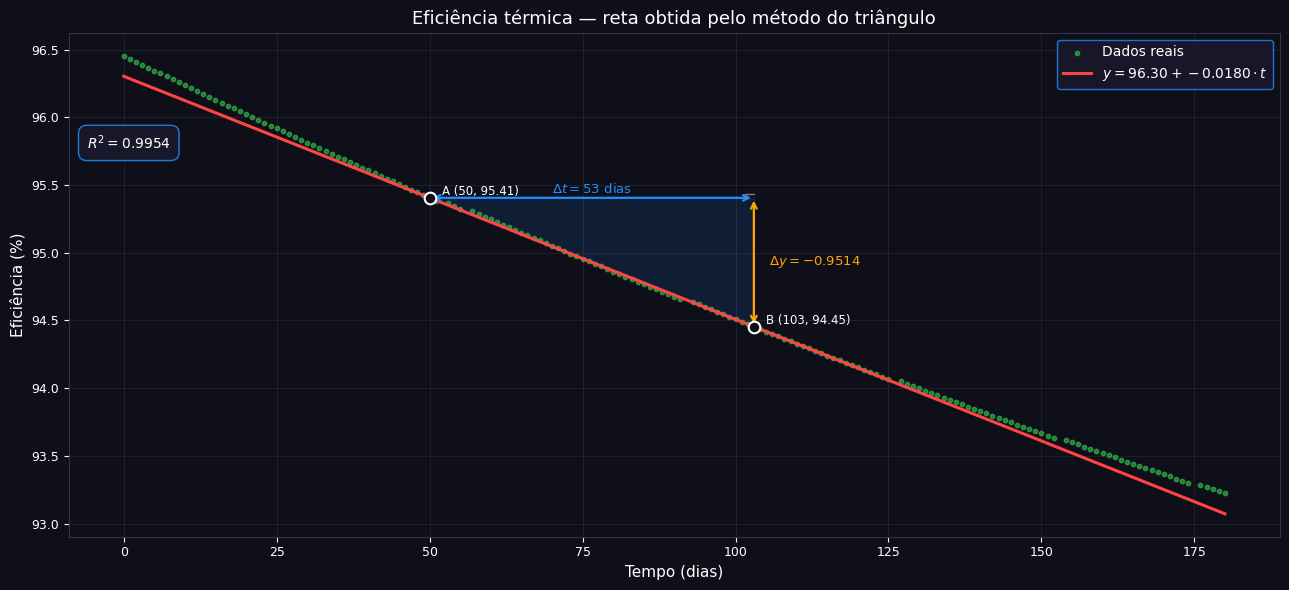


R² = 0.995422  →  99.54% da variação explicada pelo modelo


In [9]:
y_pred = beta0 + beta1 * t

# R² com numpy puro
ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - y.mean()) ** 2)
r2 = 1 - ss_res / ss_tot

# ── Layout ──────────────────────────────────────────────────────────────────
BG      = "#0f0f1a"
ACCENT  = "#1E90FF"
RED     = "#FF4444"
ORANGE  = "#FFA500"
GREEN   = "#39d353"

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

# Dados e reta
ax.scatter(t, y, s=10, alpha=0.55, color=GREEN, label="Dados reais", zorder=2)
ax.plot(t, y_pred, color=RED, linewidth=2.2, zorder=3,
        label=f"$y = {beta0:.2f} + {beta1:.4f} \\cdot t$")

# ── Triângulo ───────────────────────────────────────────────────────────────
# Preencher área
ax.fill([t1, t2, t2], [y1, y1, y2], color=ACCENT, alpha=0.12, zorder=1)

# Cateto horizontal (base)
ax.annotate("", xy=(t2, y1), xytext=(t1, y1),
            arrowprops=dict(arrowstyle="<->", color=ACCENT, lw=1.6))
ax.text((t1 + t2) / 2, y1 + 0.015,
        f"$\\Delta t = {delta_t:.0f}$ dias",
        ha="center", va="bottom", fontsize=9.5, color=ACCENT)

# Cateto vertical (altura)
ax.annotate("", xy=(t2, y2), xytext=(t2, y1),
            arrowprops=dict(arrowstyle="<->", color=ORANGE, lw=1.6))
ax.text(t2 + 2.5, (y1 + y2) / 2,
        f"$\\Delta y = {delta_y:.4f}$",
        ha="left", va="center", fontsize=9.5, color=ORANGE)

# Ângulo reto no vértice
sq = 1.5
ax.plot([t2 - sq, t2 - sq, t2], [y1, y1 + sq * abs(beta1), y1 + sq * abs(beta1)],
        color="gray", linewidth=1, zorder=4)

# Pontos A e B
for tx, yx, lbl in [(t1, y1, f"A ({t1:.0f}, {y1:.2f})"),
                    (t2, y2, f"B ({t2:.0f}, {y2:.2f})")]:
    ax.scatter(tx, yx, color=BG, edgecolors="white", s=70, zorder=6, linewidths=1.5)
    ax.text(tx + 2, yx + 0.02, lbl, fontsize=8.5, color="white", zorder=7)

# ── Caixa de métricas ───────────────────────────────────────────────────────
info = (
    f"$R^2 = {r2:.4f}$"
)
ax.text(0.015, 0.8, info,
        transform=ax.transAxes,
        va="top", ha="left",
        fontsize=10, color="white",
        bbox=dict(boxstyle="round,pad=0.6", facecolor="#1a1a2e",
                  edgecolor=ACCENT, alpha=0.85),
        linespacing=1.9)

# ── Estética ────────────────────────────────────────────────────────────────
for spine in ax.spines.values():
    spine.set_edgecolor("#333355")
ax.tick_params(colors="white", labelsize=9)
ax.xaxis.label.set_color("white")
ax.yaxis.label.set_color("white")
ax.title.set_color("white")
ax.legend(facecolor="#1a1a2e", labelcolor="white", fontsize=10,
          edgecolor=ACCENT, loc="upper right")
ax.grid(True, alpha=0.15, color="gray")
ax.set_xlabel("Tempo (dias)", fontsize=11)
ax.set_ylabel("Eficiência (%)", fontsize=11)
ax.set_title("Eficiência térmica — reta obtida pelo método do triângulo", fontsize=13)

plt.tight_layout()
plt.show()

print(f"\nR² = {r2:.6f}  →  {r2*100:.2f}% da variação explicada pelo modelo")

---
## <span style="color:#1E90FF;">7. Previsão: Quando Limpar o Trocador?</span>

Abaixo de **92%** de eficiência, o trocador precisa de limpeza. Da equação da reta, isolamos $t$:

$$y_{\text{alvo}} = \beta_0 + \beta_1 \cdot t \implies t = \frac{y_{\text{alvo}} - \beta_0}{\beta_1}$$

In [6]:
from datetime import timedelta

alvo = 92.0
t_limpeza = (alvo - beta0) / beta1
data_limpeza = dia_zero + timedelta(days=t_limpeza)

print(f"Eficiência alvo  : {alvo}%")
print(f"Dias até atingir : {t_limpeza:.1f} dias a partir de {dia_zero.date()}")
print(f"Data de limpeza  : {data_limpeza.strftime('%Y-%m-%d')}")

Eficiência alvo  : 92.0%
Dias até atingir : 239.7 dias a partir de 2022-01-01
Data de limpeza  : 2022-08-28


---
## <span style="color:#1E90FF;">8. O que Aprendemos</span>

| Conceito | O que fizemos |
|---|---|
| **Modelo** | Reta $y = \beta_0 + \beta_1 \cdot t$ |
| **β₁** | Razão entre catetos do triângulo: $\Delta y / \Delta t$ |
| **β₀** | Isolado pela substituição de um ponto |
| **Limitação** | Escolhemos os pontos **manualmente** — a reta depende dessa escolha |

### O problema que surge

Pontos diferentes geram retas diferentes. Como saber qual é a **melhor reta** para os dados?

Na **Aula 1** desenvolveremos um método automático — **gradiente descendente** — que busca a reta que **minimiza o erro** em todos os pontos ao mesmo tempo.